In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Give Dataset Path

In [3]:
data_dir = "/content/drive/MyDrive/plant disease/dataset/"

In [4]:
import os
print(os.listdir(data_dir))

['Potato___Early_blight', 'Potato___Late_blight', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight']


In [5]:
# Set Parameters
img_size = 224
batch_size = 32

Load Dataset

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

Found 6500 files belonging to 5 classes.
Using 5200 files for training.
Found 6500 files belonging to 5 classes.
Using 1300 files for validation.


In [7]:
# Get Class Names

class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']


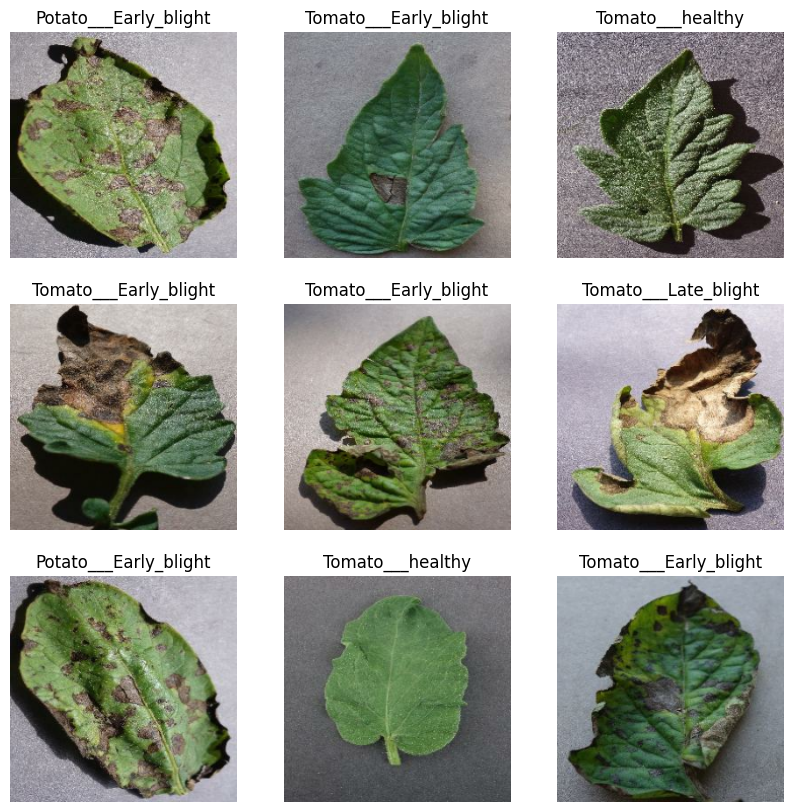

In [8]:
# Visualize Images
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

Normalize Images

In [9]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Speed Optimization

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

###Build CNN Model

In [11]:
from tensorflow.keras import models, layers

model = models.Sequential([

    # 1st Convolution Layer
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    # 2nd Convolution Layer
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # 3rd Convolution Layer
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Flatten (convert 2D → 1D)
    layers.Flatten(),

    # Dense Layer
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
# Train Model

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2016s 5s/step - accuracy: 0.6785 - loss: 0.8581 - val_accuracy: 0.8115 - val_loss: 0.4619
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 580s 4s/step - accuracy: 0.8717 - loss: 0.3500 - val_accuracy: 0.8800 - val_loss: 0.3081
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 571s 4s/step - accuracy: 0.9192 - loss: 0.2177 - val_accuracy: 0.9162 - val_loss: 0.2503
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 573s 4s/step - accuracy: 0.9492 - loss: 0.1400 - val_accuracy: 0.8769 - val_loss: 0.3846
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 623s 4s/step - accuracy: 0.9750 - loss: 0.0795 - val_accuracy: 0.9000 - val_loss: 0.3204
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 571s 4s/step - accuracy: 0.9804 - loss: 0.0629 - val_accuracy: 0.9046 - val_loss: 0.3281
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 571s 4s/step - accuracy: 0.9723 - loss: 0.0807 - val_accuracy: 0.9162 - val_loss: 0.3154
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 572s 4s/step - accuracy: 0.9867 - loss: 0.0360 - val_acc

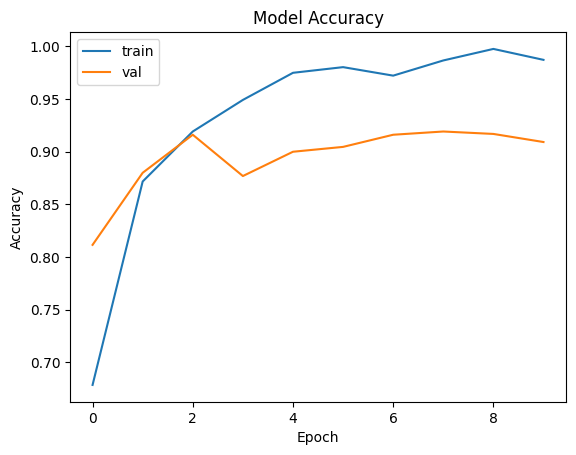

In [14]:
# Plot Accuracy Graph

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')

plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [15]:
# Save Model

model.save("plant_disease_model.h5")

###Prediction System

In [16]:
import tensorflow as tf

# Load trained model
model = tf.keras.models.load_model("plant_disease_model.h5")

In [17]:
# Upload Image in Colab

from google.colab import files
uploaded = files.upload()

Saving th.jfif to th.jfif


In [18]:
# Preprocess Image

from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

# Convert to batch
img_array = np.expand_dims(img_array, axis=0)

# Normalize
img_array = img_array / 255.0

In [19]:
# Make Prediction

predictions = model.predict(img_array)

class_idx = np.argmax(predictions)
confidence = np.max(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


In [20]:
class_names = ['Potato___Early_blight', 'Potato___Late_blight', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']

In [21]:
print("Prediction:", class_names[class_idx])
print("Confidence:", confidence)

Prediction: Tomato___Late_blight
Confidence: 0.99999213


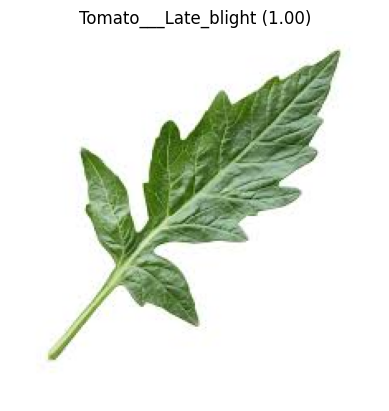

In [22]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"{class_names[class_idx]} ({confidence:.2f})")
plt.axis("off")
plt.show()